# Multimodal (audio-visual) analysis
> This script is running for experiment with auditory and visual (objects) trials.

In [1]:
import datajoint as dj
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import itertools
import pandas as pd
import os
from IPython.display import display, HTML
from scipy.stats import sem

# Style of plots
small_size=8
medium_size=20
large_size=40
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['pdf.fonttype'] =42
mpl.rcParams['axes.grid']=False
mpl.rcParams['axes.titlesize']=small_size
mpl.rcParams["figure.titlesize"] = medium_size
mpl.rcParams['axes.labelsize']=small_size
mpl.rcParams['xtick.labelsize']=small_size
mpl.rcParams['ytick.labelsize']=small_size
mpl.rcParams['legend.fontsize']=small_size


dj.config["enable_python_native_blobs"] = True
dj.config['database.host'] = 'database.eflab.org:3306'
dj.config['database.password'] = os.getenv('DJ_PASSWORD')


schemata = {'exp'   : 'lab_experiments',
            'stim'  : 'lab_stimuli',
            'beh'   : 'lab_behavior',
            'inter' : 'lab_interface',
            'rec'   :'lab_recordings',
            'mice' : 'lab_mice'}

# create a virtual module for every database schema that you are going to use
for schema, value in schemata.items():
    globals()[schema] = dj.create_virtual_module(schema, value, create_tables=True, create_schema=True)


Please enter DataJoint username:  eflab
Please enter DataJoint password:  ········


[2026-05-28 18:13:43,457][INFO]: Connecting eflab@database.eflab.org:3306
[2026-05-28 18:13:43,540][INFO]: Connected eflab@database.eflab.org:3306


In [17]:
# complete the2key
animal_id = 0
from_session = 10806
to_session = 10806

# exclude sessions from plotting
# manual_exclusion_sessions = list(range(180, 280)) + [318,320,322]
manual_exclusion_sessions = [0]

# Distribution of each condition across sessions

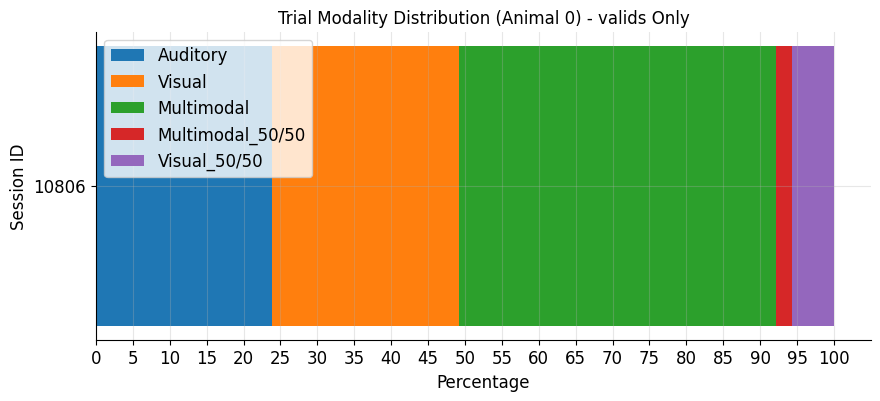

In [18]:
restr = exp.Session() & {'animal_id': animal_id}
valid_sessions = (restr - exp.Session.Excluded).fetch('session')

sessions = []

auditory_pct = []
visual_pct = []
multimodal_pct = []
multimodal_215_pct = []
visual_215_pct = []


for session in range(from_session, to_session + 1):
    if session not in valid_sessions:
        continue
    
    if session in manual_exclusion_sessions:
        continue

    key = {'animal_id': animal_id, "session":session}

    # auditory conditions = obj_mag = 0 & tone_volume > 0 ---------------------------------------------------------------
    auditory_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        # exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume > 0'
        & key
        # & 'state in ("Reward", "Punish")'
        # & 'state in ("Abort")'
    ).fetch(format='frame').reset_index()
    
    auditory_stateonset['obj_mag'] = pd.to_numeric(auditory_stateonset['obj_mag'], errors='coerce')
    auditory_stateonset = auditory_stateonset[auditory_stateonset['obj_mag'] == 0]

    # visual conditions = obj_mag > 0 & tone_volume = 0 ---------------------------------------------------------------
    visual_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        # exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume = 0'
        & key
        & 'obj_id != 215'
        # & 'state in ("Reward", "Punish")'
        # & 'state in ("Abort")'
    ).fetch(format='frame').reset_index()
    
    visual_stateonset['obj_mag'] = pd.to_numeric(visual_stateonset['obj_mag'], errors='coerce')
    visual_stateonset = visual_stateonset[visual_stateonset['obj_mag'] > 0]

    # multimodal conditions = obj_mag > 0 & tone_volume > 0 ---------------------------------------------------------------
    multi_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        # exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume > 0'
        & key
        & 'obj_id != 215'
        # & 'state in ("Reward", "Punish")'
        # & 'state in ("Abort")'
    ).fetch(format='frame').reset_index()
    
    multi_stateonset['obj_mag'] = pd.to_numeric(multi_stateonset['obj_mag'], errors='coerce')
    multi_stateonset = multi_stateonset[multi_stateonset['obj_mag'] > 0]

    # multimodal 50-50 conditions = obj_mag > 0 & tone_volume > 0 ---------------------------------------------------------------
    multi215_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        # exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume > 0'
        & key
        & 'obj_id=215'
        # & 'state in ("Reward", "Punish", "Abort")'
        # & 'state in ("Abort")'
    ).fetch(format='frame').reset_index()
    
    multi215_stateonset['obj_mag'] = pd.to_numeric(multi215_stateonset['obj_mag'], errors='coerce')
    multi215_stateonset = multi215_stateonset[multi215_stateonset['obj_mag'] > 0]

    # visual 50-50 conditions = obj_mag > 0 & tone_volume > 0 ---------------------------------------------------------------
    visual215_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        # exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume = 0'
        & key
        & 'obj_id=215'
        # & 'state in ("Reward", "Punish", "Abort")'
        # & 'state in ("Abort")'
    ).fetch(format='frame').reset_index()
    
    visual215_stateonset['obj_mag'] = pd.to_numeric(visual215_stateonset['obj_mag'], errors='coerce')
    visual215_stateonset = visual215_stateonset[visual215_stateonset['obj_mag'] > 0]


    # ---- replace with real per-session computation ----
    auditory_trials = len(auditory_stateonset)
    visual_trials = len(visual_stateonset)
    multimodal_trials = len(multi_stateonset)
    visual215_trials = len(visual215_stateonset)
    multi215_trials = len(multi215_stateonset)

    sizes = np.array([auditory_trials, visual_trials, multimodal_trials, multi215_trials, visual215_trials])
    total = sizes.sum()

    if total == 0:
        continue

    sessions.append(session)
    auditory_pct.append(sizes[0] / total * 100)
    visual_pct.append(sizes[1] / total * 100)
    multimodal_pct.append(sizes[2] / total * 100)
    multimodal_215_pct.append(sizes[3] / total * 100)
    visual_215_pct.append(sizes[4] / total * 100)

# convert to numpy arrays (IMPORTANT for alignment)
auditory_pct = np.array(auditory_pct)
visual_pct = np.array(visual_pct)
multimodal_pct = np.array(multimodal_pct)
multimodal_215_pct = np.array(multimodal_215_pct)
visual_215_pct = np.array(visual_215_pct)

y = np.arange(len(sessions))  # <-- THIS fixes alignment

plt.figure(figsize=(10, max(4, len(sessions) * 0.3)))

plt.barh(y, auditory_pct, label='Auditory')
plt.barh(y, visual_pct, left=auditory_pct, label='Visual')
plt.barh(y, multimodal_pct, left=auditory_pct + visual_pct, label='Multimodal')
plt.barh(y, multimodal_215_pct, left=auditory_pct + visual_pct + multimodal_pct, label='Multimodal_50/50')
plt.barh(y, visual_215_pct,left=auditory_pct + visual_pct + multimodal_pct + multimodal_215_pct, label='Visual_50/50')


plt.yticks(y, sessions)   # <-- correct session labels aligned to bars

plt.xticks(range(0, 101, 5))
plt.xlabel('Percentage', fontsize=12)
plt.ylabel('Session ID', fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.title(f'Trial Modality Distribution (Animal {animal_id}) - valids Only', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.show()

## Scatter plot beetween modalites across sessions

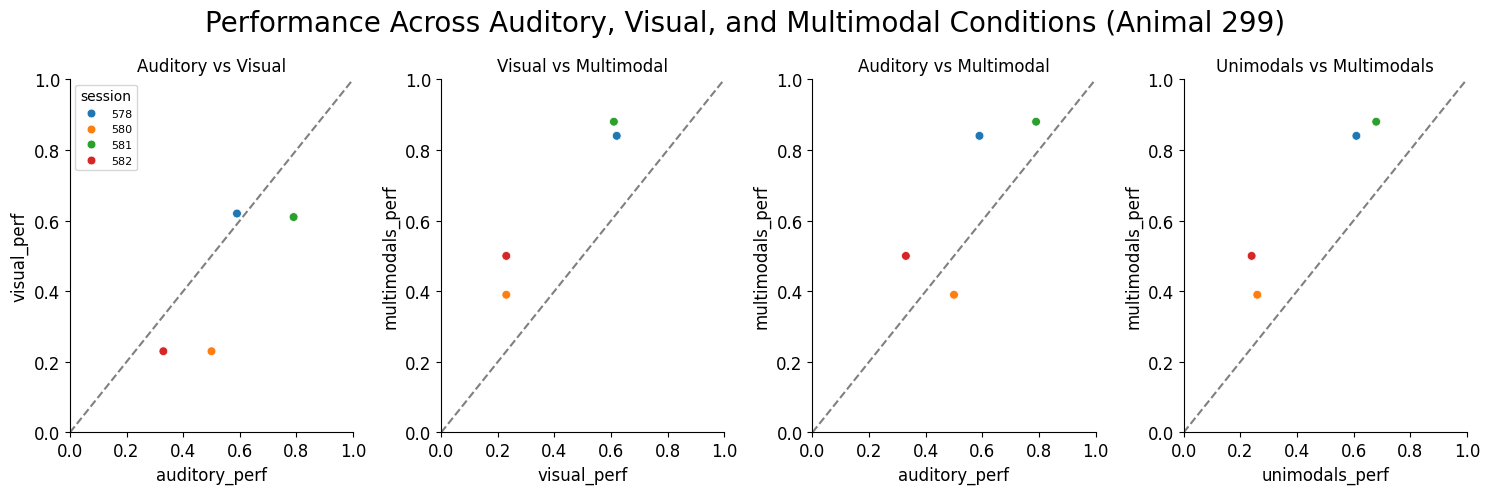

Skipped sessions (missing one or more modalities): []


,session,auditory_perf,visual_perf,multi_perf,uni_perf
0,578,0.59,0.62,0.84,0.61
1,580,0.50,0.23,0.39,0.26
2,581,0.79,0.61,0.88,0.68
3,582,0.33,0.23,0.50,0.24


In [4]:
restr = exp.Session() & {'animal_id': animal_id}
valid_sessions = (restr - exp.Session.Excluded).fetch('session')

perf_per_condition = []
skipped_sessions = []

for session in range(from_session, to_session + 1):
    if session not in valid_sessions:
        continue

    key = {'animal_id': animal_id, "session":session}

    # auditory conditions = obj_mag = 0 & tone_volume > 0
    auditory_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume > 0'
        & key
        & 'state in ("Reward", "Punish")'
    ).fetch(format='frame').reset_index()
    
    auditory_stateonset['obj_mag'] = pd.to_numeric(auditory_stateonset['obj_mag'], errors='coerce')
    auditory_stateonset = auditory_stateonset[auditory_stateonset['obj_mag'] == 0]

    # visual conditions = obj_mag > 0 & tone_volume = 0
    visual_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume = 0'
        & key
        & 'state in ("Reward", "Punish")'
    ).fetch(format='frame').reset_index()
    
    visual_stateonset['obj_mag'] = pd.to_numeric(visual_stateonset['obj_mag'], errors='coerce')
    visual_stateonset = visual_stateonset[visual_stateonset['obj_mag'] > 0]

    # multimodal conditions = obj_mag > 0 & tone_volume > 0
    multi_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume > 0'
        & key
        & 'state in ("Reward", "Punish")'
    ).fetch(format='frame').reset_index()
    
    multi_stateonset['obj_mag'] = pd.to_numeric(multi_stateonset['obj_mag'], errors='coerce')
    multi_stateonset = multi_stateonset[multi_stateonset['obj_mag'] > 0]

    unimodal_stateonset = (
        stim.StimCondition.Trial *
        (stim.Panda.Object).proj('obj_mag') *
        exp.Trial.StateOnset *
        (stim.Tones).proj('tone_volume')
        & key
        & 'state in ("Reward", "Punish")'
    ).fetch(format='frame').reset_index()
    
    unimodal_stateonset['obj_mag'] = pd.to_numeric(
        unimodal_stateonset['obj_mag'],
        errors='coerce'
    )
    
    unimodal_stateonset['tone_volume'] = pd.to_numeric(
        unimodal_stateonset['tone_volume'],
        errors='coerce'
    )
    
    # apply the OR condition in pandas
    unimodal_stateonset = unimodal_stateonset[
        (
            (unimodal_stateonset['obj_mag'] > 0) &
            (unimodal_stateonset['tone_volume'] == 0)
        )
        |
        (
            (unimodal_stateonset['obj_mag'] == 0) &
            (unimodal_stateonset['tone_volume'] > 0)
        )
    ]

     # Skip sessions missing ANY modality
    if (
        len(auditory_stateonset) == 0 or
        len(visual_stateonset) == 0 or
        len(multi_stateonset) == 0
    ):
        skipped_sessions.append(session)
        continue

    # Calculate the performance in each condition
    visual_perf = round((visual_stateonset['state'] == 'Reward').mean(), 2)
    auditory_perf = round((auditory_stateonset['state'] == 'Reward').mean(), 2)
    multi_perf = round((multi_stateonset['state'] == 'Reward').mean(), 2)
    uni_perf = round((unimodal_stateonset['state'] == 'Reward').mean(), 2)

    perf_per_condition.append({
        'session': session,
        'auditory_perf': auditory_perf,
        'visual_perf': visual_perf,
        'multi_perf': multi_perf,
        'uni_perf': uni_perf,
    })
    
perf_per_condition = pd.DataFrame(perf_per_condition)

perf_per_condition['session'] = perf_per_condition['session'].astype(str)

# plotting =======================
fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=False)

# Auditory vs Visual
sns.scatterplot(
    data=perf_per_condition,
    x='auditory_perf',
    y='visual_perf',
    ax=axes[0],
    hue='session',
    s=40
)
axes[0].set_title('Auditory vs Visual', fontsize=12)
axes[0].set_ylabel('visual_perf', fontsize=12)
axes[0].set_xlabel('auditory_perf', fontsize=12)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].axline((0, 0), slope=1, linestyle='--', color='gray')

# Visual vs Multimodal
sns.scatterplot(
    data=perf_per_condition,
    x='visual_perf',
    y='multi_perf',
    ax=axes[1],
    hue='session',
    s=40,
    legend=False
)
axes[1].set_title('Visual vs Multimodal', fontsize=12)
axes[1].set_ylabel('multimodals_perf', fontsize=12)
axes[1].set_xlabel('visual_perf', fontsize=12)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axline((0, 0), slope=1, linestyle='--', color='gray')

# Auditory vs Multimodal
sns.scatterplot(
    data=perf_per_condition,
    x='auditory_perf',
    y='multi_perf',
    ax=axes[2],
    hue='session',
    s=40,
    legend=False
)
axes[2].set_title('Auditory vs Multimodal', fontsize=12)
axes[2].set_ylabel('multimodals_perf', fontsize=12)
axes[2].set_xlabel('auditory_perf', fontsize=12)
axes[2].tick_params(axis='both', labelsize=12)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].axline((0, 0), slope=1, linestyle='--', color='gray')

# Unimodals vs Multimodal
sns.scatterplot(
    data=perf_per_condition,
    x='uni_perf',
    y='multi_perf',
    ax=axes[3],
    hue='session',
    s=40,
    legend=False
)
axes[3].set_title('Unimodals vs Multimodals', fontsize=12)
axes[3].set_ylabel('multimodals_perf', fontsize=12)
axes[3].set_xlabel('unimodals_perf', fontsize=12)
axes[3].tick_params(axis='both', labelsize=12)
axes[3].set_xlim(0, 1)
axes[3].set_ylim(0, 1)
axes[3].axline((0, 0), slope=1, linestyle='--', color='gray')

plt.suptitle(f'Performance Across Auditory, Visual, and Multimodal Conditions (Animal {animal_id})')

plt.tight_layout()
plt.show()


print("Skipped sessions (missing one or more modalities):", skipped_sessions)
display(perf_per_condition)

In [5]:
## Statistical significant difference between conditions (paired t-test) -- ΤοDo

# Performance for object id across sessions

## Performance in <b>unimodal visual<b> trials 

In [130]:
from multimodal_functions import visual_df, plot_visual_performance

key = {
    'animal_id': animal_id,
    'sessions': (from_session, to_session), # define the session range (from_session, to_session)
    'difficulties': [2, 3, 0, 0], # define the difficulties
    'object_ids': [211,212,213,214,215,216,217,218,219], # define the obj_ids that you want
    'excluded_sessions': [] #define the sessions that you want to exclude from the analysis
}

[2026-05-27 22:39:01,906][WARNING]: MySQL server has gone away. Reconnecting to the server.


Object 212:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,299,580,2026-05-27 09:28:18,155,9,0.56,5,4,3


Object 213:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,299,580,2026-05-27 09:28:18,155,3,1.0,3,0,1


...

,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,299,580,2026-05-27 09:28:18,155,38,0.0,0,38,15


Object 218:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,299,580,2026-05-27 09:28:18,155,3,1.0,3,0,4


Object 219:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,299,580,2026-05-27 09:28:18,155,3,0.67,2,1,1


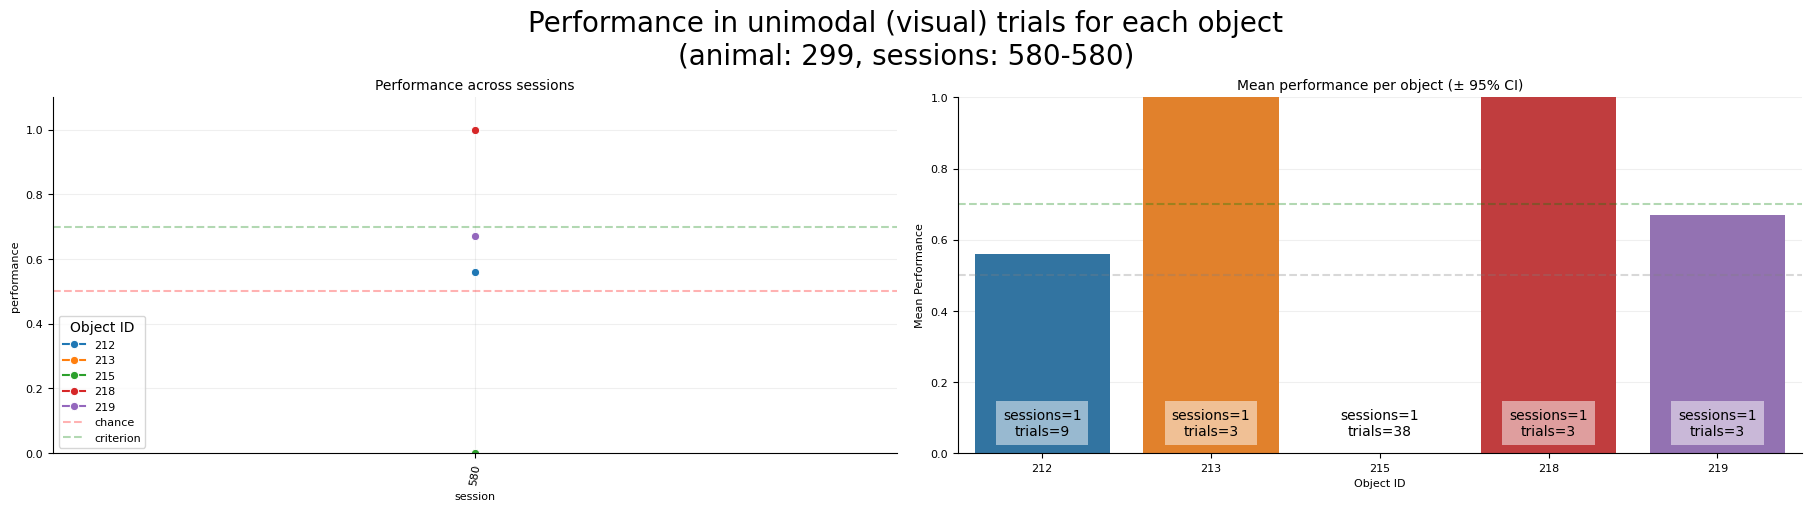

In [131]:
dfs = visual_df(key)
plot_visual_performance(key)

## Performance in <b>multimodal</b> trials 

In [137]:
restr = exp.Session() & {'animal_id': animal_id}
valid_sessions = (restr - exp.Session.Excluded).fetch('session')

perf_per_condition = []
skipped_sessions = []
empty_objects = []

# list of object ids
object_ids = [211, 212, 213, 214, 215, 216, 217,218, 219]

# Define object aliases if needed
object_aliases = {
    211: [211, 1],
    219: [219, 2]
}

object_dataframes = {}
skipped_sessions = []

for obj_id in object_ids:
    
    multimodal_trials_list = []
    
    for session in range(from_session, to_session + 1):
             
        if session not in valid_sessions:
            continue
    
        key = {
            'animal_id': animal_id, 
            'session':session
        }

        # Get all IDs to include for this object
        obj_ids_to_query = object_aliases.get(obj_id, [obj_id])
        obj_query = ' OR '.join([f'obj_id={oid}' for oid in obj_ids_to_query])


        # multimodal conditions = obj_mag > 0 & tone_volume > 0 ---------------------------------------------------------------
        multi_stateonset = (
            stim.StimCondition.Trial * 
            (stim.Panda.Object).proj('obj_mag') * 
            exp.Trial.StateOnset * 
            (stim.Tones).proj('tone_volume') 
            & 'tone_volume > 0'
            & obj_query 
            & key
            & 'state in ("Reward", "Punish",  "Abort")'
        ).fetch(format='frame').reset_index()
        
        multi_stateonset['obj_mag'] = pd.to_numeric(
            multi_stateonset['obj_mag'], 
            errors='coerce'
        )
        
        multi_stateonset = multi_stateonset[multi_stateonset['obj_mag'] > 0]

        # Skip empty session
        if multi_stateonset.empty:
            continue

        session_trials = len(
            exp.Trial 
            & key
        )

        rew = (multi_stateonset['state'] == 'Reward').sum()
        pun = (multi_stateonset['state'] == 'Punish').sum()
        abrt = (multi_stateonset['state'] == 'Abort').sum()

        M_valid_trials = rew + pun
        M_perf = round(rew / M_valid_trials, 2) if M_valid_trials > 0 else np.nan
        percentage = round((M_valid_trials / session_trials) * 100, 2) if session_trials > 0 else 0

        multimodal_trials_list.append({
            'animal_id': animal_id,
            'session': session,
            'session_trials': session_trials,
            'M_valid_trials': M_valid_trials,
            'M_percentage': percentage,
            'M_perf': M_perf,
            'M_reward': rew,
            'M_punish': pun,
            'M_abort': abrt
        })

    # Convert to DataFrame and store
    df = pd.DataFrame(multimodal_trials_list)

    if df.empty:
        empty_objects.append(obj_id)
        continue
    
    df.index = range(1, len(df) + 1)
    object_dataframes[obj_id] = df

    display(HTML(f"-------> <b>Sessions without multimodal trials:</b> {skipped_sessions}"))
    display(HTML(f"Object ID: <b>{obj_id}</b>"))
    display(df)

# Print once at the end
if empty_objects:
    print(
        "No multimodal trials for object(s):",
        ", ".join(map(str, empty_objects))
    )

,animal_id,session,session_trials,M_valid_trials,M_percentage,M_perf,M_reward,M_punish,M_abort
1,299,580,155,6,3.87,0.67,4,2,6


,animal_id,session,session_trials,M_valid_trials,M_percentage,M_perf,M_reward,M_punish,M_abort
1,299,580,155,6,3.87,0.67,4,2,0


,animal_id,session,session_trials,M_valid_trials,M_percentage,M_perf,M_reward,M_punish,M_abort
1,299,580,155,24,15.48,0.0,0,24,5


,animal_id,session,session_trials,M_valid_trials,M_percentage,M_perf,M_reward,M_punish,M_abort
1,299,580,155,6,3.87,0.83,5,1,3


,animal_id,session,session_trials,M_valid_trials,M_percentage,M_perf,M_reward,M_punish,M_abort
1,299,580,155,7,4.52,0.86,6,1,4


No multimodal trials for object(s): 211, 214, 216, 217


In [133]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Combine all per-object data
# -----------------------------
df_full = pd.concat(
    [
        df.assign(object=obj_id)
        for obj_id, df in object_dataframes.items()
    ],
    ignore_index=True
)

# rename for plotting consistency
df_full = df_full.rename(columns={
    "M_perf": "performance",
    "M_valid_trials": "valid_obj_trials"
})

# mean per object for bar plot
row_data = (
    df_full
    .groupby(["object", "session"], as_index=False)
    .agg(
        performance=("performance", "mean"),
        valid_obj_trials=("valid_obj_trials", "sum")
    )
)

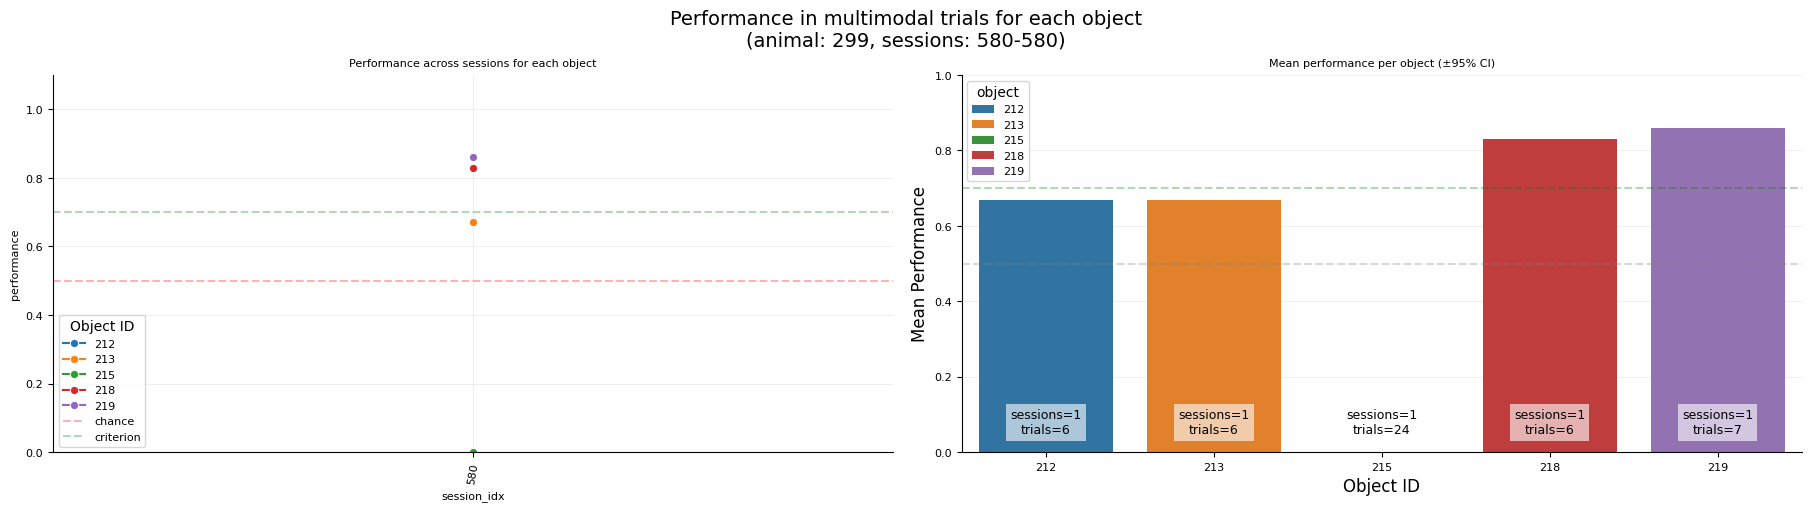

In [128]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 5),
    constrained_layout=True
)

df_full = df_full.copy()
# df_full["session"] = df_full["session"].astype(int)

# map sessions -> continuous index (0,1,2,3,...)
session_map = {s: i for i, s in enumerate(sorted(df_full["session"].unique()))}
df_full["session_idx"] = df_full["session"].map(session_map)

palette = sns.color_palette("tab10", n_colors= len(np.unique(df_full['object'])))

# ---------------------- 📈 Line Plot ----------------------
if not df_full.empty:
    sns.lineplot(
        data=df_full,
        # x='session',
        x='session_idx',
        y='performance',
        hue='object',
        marker='o',
        ax=axes[0],
        sort=False,
        palette = palette
    )

    sessions = sorted(df_full["session"].unique())

    axes[0].set_xticks(range(len(session_map)))
    axes[0].set_xticklabels(sorted(session_map.keys()), rotation=80)
    
    axes[0].set_title("Performance across sessions for each object")
    axes[0].set_ylim(0, 1.1)
    axes[0].grid(alpha=0.2)

    axes[0].axhline(0.5, color='r', linestyle='--', alpha=0.3, label='chance')
    axes[0].axhline(0.7, color='g', linestyle='--', alpha=0.3, label='criterion')

    axes[0].set_axisbelow(True)
    axes[0].tick_params(axis='x', rotation=80)
    axes[0].legend(title='Object ID')

else:
    print("🚫 No valid data found to plot.")

# ---------------------- 📊 Bar Plot ----------------------
sns.barplot(
    data=df_full,
    x='object',
    y='performance',
    hue='object',
    errorbar=('ci', 95),
    ax=axes[1],
    palette = palette

)

axes[1].set_title('Mean performance per object (±95% CI)')
axes[1].set_ylabel('Mean Performance', fontsize=12)
axes[1].set_xlabel('Object ID', fontsize=12)
axes[1].set_ylim(0, 1)

axes[1].grid(axis='y', alpha=0.2)
axes[1].axhline(0.5, color='grey', linestyle='--', alpha=0.3)
axes[1].axhline(0.7, color='green', linestyle='--', alpha=0.3)

axes[1].set_axisbelow(True)

# ---------------------- 📝 Bar annotations ----------------------
total_trials_per_object = df_full.groupby('object')['valid_obj_trials'].sum()

for i, obj in enumerate(sorted(df_full['object'].unique())):
    n_sessions = df_full[df_full['object'] == obj]['session'].nunique()
    n_trials = total_trials_per_object[obj]

    axes[1].text(
        i,
        0.05,
        f"sessions={n_sessions}\ntrials={n_trials}",
        ha='center',
        fontsize=9,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.6,
            pad=3
        )
    )

# ---------------------- 🏷️ Title ----------------------
plt.suptitle(
    f"Performance in multimodal trials for each object\n"
    f"(animal: {animal_id}, sessions: {from_session}-{to_session})",
    fontsize=14
)

plt.show()